# Multimodal assistant with Phi-4-multimodal and OpenVINO

Phi-4-multimodal-instruct is a lightweight open multimodal foundation model. The model processes text, image, and audio inputs, generating text outputs. Phi-4-multimodal-instruct has 5.6B parameters and is a multimodal transformer model. The model has the pretrained Phi-4-mini as the  backbone language model, and the advanced encoders and adapters of vision and speech.
In this tutorial we will explore how to run Phi-4-multimodal model using [OpenVINO](https://github.com/openvinotoolkit/openvino) and optimize it using [NNCF](https://github.com/openvinotoolkit/nncf).
#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Convert model to OpenVINO Intermediate Representation](#Convert-model-to-OpenVINO-Intermediate-Representation)
    - [Compress model weights to 4-bit](#Compress-model-weights-to-4-bit)
- [Create inference pipeline](#Create-inference-pipeline)
- [Run model inference](#Run-model-inference)
    - [Text-only input](#Text-only-input)
    - [Text-Image input](#Text-Image-input)
    - [Audio-text input](#Audio-text-input)
    - [Audio-only input](#Audio-only-input)
- [Interactive demo](#Interactive-demo)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/phi-4-multimodal/phi-4-multimodal.ipynb" />


## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [1]:
%pip -q install "transformers>=4.51" "torch>2.1" "torchvision" "torchaudio" soundfile Pillow "backoff" "peft==0.13.2" "gradio>=4.19" "librosa" --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -qU  "openvino>=2025.1.0" "nncf>=2.16"
%pip install -q "https://github.com/huggingface/optimum-intel.git" --extra-index-url https://download.pytorch.org/whl/cpu

In [2]:
import requests
from pathlib import Path

if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/phi-4-multimodal/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)


if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    open("cmd_helper.py", "w").write(r.text)

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

## Convert model to OpenVINO Intermediate Representation
[back to top ⬆️](#Table-of-contents:)

Phi-4-multimodal is PyTorch model. OpenVINO supports PyTorch models via conversion to OpenVINO Intermediate Representation (IR). [OpenVINO model conversion API](https://docs.openvino.ai/2024/openvino-workflow/model-preparation.html#convert-a-model-with-python-convert-model) should be used for these purposes. `ov.convert_model` function accepts original PyTorch model instance and example input for tracing and returns `ov.Model` representing this model in OpenVINO framework. Converted model can be used for saving on disk using `ov.save_model` function or directly loading on device using `core.complie_model`. 

<details>
  <summary><b>Click here for more detailed explanation of conversion steps</b></summary>
Phi-4-multimodal is autoregressive transformer generative model, it means that each next model step depends from model output from previous step. The generation approach is based on the assumption that the probability distribution of a word sequence can be decomposed into the product of conditional next word distributions. In other words, model predicts the next token in the loop guided by previously generated tokens until the stop-condition will be not reached (generated sequence of maximum length or end of string token obtained). The way the next token will be selected over predicted probabilities is driven by the selected decoding methodology. You can find more information about the most popular decoding methods in this <a href="https://huggingface.co/blog/how-to-generate">blog</a>. The entry point for the generation process for models from the Hugging Face Transformers library is the `generate` method. You can find more information about its parameters and configuration in the  <a href="https://huggingface.co/docs/transformers/v4.26.1/en/main_classes/text_generation#transformers.GenerationMixin.generate">documentation</a>. To preserve flexibility in the selection decoding methodology, we will convert only model inference for one step.

Phi-4-multimodal model consists of 4 parts:

* **Vision Embeddings Model** for encoding input images into embedding space.
* **Text Embeddings Model** for conversion input text tokens into embedding space.
* **Audio Embeddings Model** for encoding input audio into embedding space
* **Language Model** for generation answer based on input embeddings provided by Image Encoder and Input Embedding models.

</details>

For convenience, we will use OpenVINO integration with HuggingFace Optimum. 🤗 [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) is the interface between the 🤗 Transformers and Diffusers libraries and the different tools and libraries provided by Intel to accelerate end-to-end pipelines on Intel architectures.

Among other use cases, Optimum Intel provides a simple interface to optimize your Transformers and Diffusers models, convert them to the OpenVINO Intermediate Representation (IR) format and run inference using OpenVINO Runtime. `optimum-cli` provides command line interface for model conversion and optimization. 

General command format:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

where task is task to export the model for, if not specified, the task will be auto-inferred based on the model. You can find a mapping between tasks and model classes in Optimum TaskManager [documentation](https://huggingface.co/docs/optimum/exporters/task_manager). Additionally, you can specify weights compression using `--weight-format` argument with one of following options: `fp32`, `fp16`, `int8` and `int4`. Fro int8 and int4 [nncf](https://github.com/openvinotoolkit/nncf) will be used for  weight compression. More details about model export provided in [Optimum Intel documentation](https://huggingface.co/docs/optimum/intel/openvino/export#export-your-model).


### Compress model weights to 4-bit
[back to top ⬆️](#Table-of-contents:)
For reducing memory consumption, weights compression optimization can be applied using [NNCF](https://github.com/openvinotoolkit/nncf). 

<details>
    <summary><b>Click here for more details about weight compression</b></summary>
Weight compression aims to reduce the memory footprint of a model. It can also lead to significant performance improvement for large memory-bound models, such as Large Language Models (LLMs). LLMs and other models, which require extensive memory to store the weights during inference, can benefit from weight compression in the following ways:

* enabling the inference of exceptionally large models that cannot be accommodated in the memory of the device;

* improving the inference performance of the models by reducing the latency of the memory access when computing the operations with weights, for example, Linear layers.

[Neural Network Compression Framework (NNCF)](https://github.com/openvinotoolkit/nncf) provides 4-bit / 8-bit mixed weight quantization as a compression method primarily designed to optimize LLMs. The main difference between weights compression and full model quantization (post-training quantization) is that activations remain floating-point in the case of weights compression which leads to a better accuracy. Weight compression for LLMs provides a solid inference performance improvement which is on par with the performance of the full model quantization. In addition, weight compression is data-free and does not require a calibration dataset, making it easy to use.

`nncf.compress_weights` function can be used for performing weights compression. The function accepts an OpenVINO model and other compression parameters. Compared to INT8 compression, INT4 compression improves performance even more, but introduces a minor drop in prediction quality.

More details about weights compression, can be found in [OpenVINO documentation](https://docs.openvino.ai/2024/openvino-workflow/model-optimization-guide/weight-compression.html).
</details>

In [3]:
from pathlib import Path

model_id = "microsoft/phi-4-multimodal-instruct"

base_model_path = Path(model_id.split("/")[-1])

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("phi-4-multimodal.ipynb")

In [4]:
import ipywidgets as widgets

to_compress = widgets.Checkbox(value=True, description="Compress model", disabled=False)

to_compress

Checkbox(value=True, description='Compress model')

In [10]:
from cmd_helper import optimum_cli

additional_args = {"trust-remote-code": "", "task": "image-text-to-text"}
additional_args["weight-format"] = "int4" if to_compress.value else "fp16"
model_path = base_model_path / ("INT4" if to_compress.value else "FP16")
if to_compress.value:
    additional_args["group-size"] = "64"

if not model_path.exists():
    optimum_cli(model_id, model_path, additional_args=additional_args)

**Export command:**

`optimum-cli export openvino --model microsoft/phi-4-multimodal-instruct phi-4-multimodal-instruct/INT4 --trust-remote-code --task image-text-to-text --weight-format int4 --group-size 64`

## Create inference pipeline
[back to top ⬆️](#Table-of-contents:)

OpenVINO integration with Optimum Intel provides ready-to-use API for model inference that can be used for smooth integration with transformers-based solutions. For loading model, we will use `OVModelForVisualCausalLM` class that have compatible interface with Transformers Qwen2.5VL implementation. For loading a model, `from_pretrained` method should be used. It accepts path to the model directory or model_id from HuggingFace hub (if model is not converted to OpenVINO format, conversion will be triggered automatically). Additionally, we can provide an inference device, quantization config (if model has not been quantized yet) and device-specific OpenVINO Runtime configuration. More details about model inference with Optimum Intel can be found in [documentation](https://huggingface.co/docs/optimum/intel/openvino/inference).

In [11]:
from notebook_utils import device_widget

device = device_widget(exclude=["NPU"])
device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

In [12]:
from transformers import AutoProcessor, TextStreamer
from optimum.intel.openvino import OVModelForVisualCausalLM

processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)
ov_model = OVModelForVisualCausalLM.from_pretrained(model_path, device=device.value, trust_remote_code=True)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Run model inference
[back to top ⬆️](#Table-of-contents:)

Let's explore model capabilities using multimodal input

### Text-only input
[back to top ⬆️](#Table-of-contents:)

In [13]:
conversation = [{"role": "user", "content": "What is the answer for 1+1? Explain it."}]
prompt = processor.tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)

inputs = processor(text=prompt, images=None, return_tensors="pt")
print("Question:\nWhat is the answer for 1+1? Explain it.")
print("Answer:")

generate_ids = ov_model.generate(**inputs, max_new_tokens=50, streamer=TextStreamer(processor.tokenizer, skip_prompt=True, skip_special_tokens=True))

Question:
What is the answer for 1+1? Explain it.
Answer:
The answer for 1+1 is 2. This is because when you add one to another one, you get a total of two. It's a basic principle of addition in mathematics.


### Text-Image input
[back to top ⬆️](#Table-of-contents:)

Question:
What is unusual on this picture?


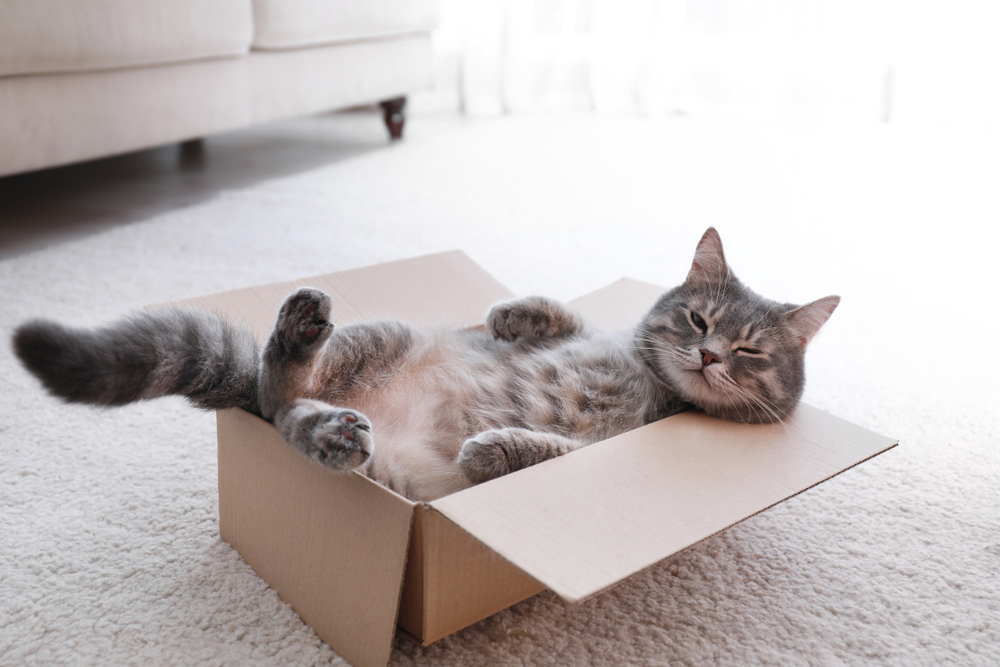

Answer:
The cat is lying in a box on the floor.


In [14]:
import requests
from PIL import Image
from io import BytesIO

image_path = Path("cat.png")

IMAGE_SPECIAL = "<|endoftext10|>"
AUDIO_SPECIAL = "<|endoftext11|>"

if not image_path.exists():
    url = "https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/d5fbbd1a-d484-415c-88cb-9986625b7b11"
    image = Image.open(BytesIO(requests.get(url).content))
    image.save(image_path)
else:
    image = Image.open(image_path)

conversation = [{"role": "user", "content": f"{IMAGE_SPECIAL}What is unusual on this picture?"}]

prompt = processor.tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)

inputs = processor(text=prompt, images=[image], return_tensors="pt")

print("Question:\nWhat is unusual on this picture?")
display(image)
print("Answer:")

generate_ids = ov_model.generate(**inputs, max_new_tokens=100, streamer=TextStreamer(processor.tokenizer, skip_prompt=True, skip_special_tokens=True))

### Audio-text input
[back to top ⬆️](#Table-of-contents:)

In [15]:
import soundfile
from notebook_utils import download_file
import IPython


question = (
    "Transcribe the audio to text, and then translate the audio to  French. Use <sep> as a separator between the original transcript and the translation."
)
conversation = [{"role": "user", "content": f"{AUDIO_SPECIAL}{question}"}]
prompt = processor.tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)
if not Path("Trailer.wav").exists():
    download_file("https://voiceage.com/wbsamples/in_mono/Trailer.wav", "Trailer.wav")

audio = soundfile.read("Trailer.wav")
inputs = processor(text=prompt, audios=[audio], return_tensors="pt")

print(f"Question:\n{question}")
display(IPython.display.Audio("Trailer.wav"))

print("Answer:")
generate_ids = ov_model.generate(**inputs, max_new_tokens=1000, streamer=TextStreamer(processor.tokenizer, skip_prompt=True, skip_special_tokens=True))

Question:
Transcribe the audio to text, and then translate the audio to  French. Use <sep> as a separator between the original transcript and the translation.


Answer:
No matter what your format is, you need to keep things exciting. <sep> Peu importe votre format, vous devez garder les choses excitantes.


### Audio-only input
[back to top ⬆️](#Table-of-contents:)

In [16]:
conversation = [{"role": "user", "content": f"{AUDIO_SPECIAL}"}]
prompt = processor.tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)

if not Path("how_are_you_doing_today.wav").exists():
    download_file("https://storage.openvinotoolkit.org/models_contrib/speech/2021.2/librispeech_s5/how_are_you_doing_today.wav", "how_are_you_doing_today.wav")
audio_question = soundfile.read("how_are_you_doing_today.wav")

inputs = processor(text=prompt, audios=[audio_question], return_tensors="pt")

print("Question:")
display(IPython.display.Audio("how_are_you_doing_today.wav"))

print("Answer:")
generate_ids = ov_model.generate(**inputs, max_new_tokens=15, streamer=TextStreamer(processor.tokenizer, skip_prompt=True, skip_special_tokens=True))

Question:


Answer:
I'm doing well, thank you! How about you?


## Interactive demo
[back to top ⬆️](#Table-of-contents:)

In [17]:
from gradio_helper import make_demo

demo = make_demo(ov_model, processor)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/